## <center> Machine Learning from Scratch at ETH Zurich
## <center> 5. From Decision Trees to Random Forests
### <center> Zhaorui Gong &nbsp; 宫兆瑞

### 5.1 简单决策树的数学原理与手动实现

#### 5.1.1 定义与背景
Given dataset D and classes $C_1, ..., C_k$, we denote the proportion of each class in the dataset as $ p_i = \frac{|C_i|}{|D|}$, for $i = 1, ..., k$.

We define Entropy(信息熵) as:
$$
H(D) = - \sum_{i=1}^{k}p_i\,log_{2}(p_i)
$$
Remark: 

熵描述随机变量（在这里为数据集分类）的不确定性。熵越大，说明不确定性越大，数据集中包含的类别越杂乱。当各类样本均匀分布时，熵最大 ($log_2c$)。相反，如果数据集中只有一类数据，则$p = \frac{|D|}{|D|} = 1$，于是$H(D) = 0$. 注意定义中的log以2为底，也可以以e，不影响熵的规模比较，比如相对熵，也就是著名的KL-Divergence.

Define the Conditional Entropy（条件熵） as: 
$$
H(D|A) = - \sum_{i \in Values(A)}\frac{|D_i|}{|D|} \;H(D_i)
$$
for some feature $A$, $D_i$ 指特征$A$取值为i的数据类别。

Remark: 

    Conditional Entropy 描述已知特征$A$ 后的剩余不确定性。

Define the Information Gain （信息增益） as:
$$
IG(D, A) = H(D) - H(D|A)
$$
Remark: 

1. 信息增益通过特征 $A$ 划分数据后熵的减少量，衡量特征的重要性。信息增益越大，说明特征$A$ 对分类的贡献越大。

2. 信息增益的局限性：偏向选择取值较多的特征（例如“ID”作为primary key是独特的，特征的信息增益最大但无意义）。改进方法：信息增益比（Gain Ratio），对特征取值数进行归一化。

#### 5.1.2 ID3算法步骤
1. 计算数据集的初始熵 H(D)。

2. 对每个feature A，计算条件熵 H(D∣A) 和信息增益 IG(D,A)。

3. 选择信息增益最大的特征作为当前节点的分裂依据。WHY? 通过最大化信息增益，选择能最有效降低不确定性的特征，从而快速逼近纯净的分类结果。

4. 对子集递归重复上述过程，直到终止条件（如纯度达100%或深度限制）。

#### 5.1.3 手动代码实现


In [3]:
import numpy as np
import pandas as pd
from collections import Counter

class DecisionTreeID3:
    def __init__(self, max_depth=10):
        self.max_depth = max_depth  # 防止过拟合的树杈深度限制，类似于梯度下降的max_iter
        self.tree = None

    def fit(self, X, y, features):
        """
        训练决策树
        :param X: 特征数据（二维列表/数组，每行一个样本）
        :param y: 标签列表
        :param features: 特征名称列表（与X列对应）
        """
        if isinstance(X, pd.DataFrame):    # 我们要传入二维数组，方便indexing，所以把pd数据框转换一下。
            X = X.values.tolist()
            y = y.tolist()
        self.tree = self._build_tree(X, y, features, depth=0)

    def _build_tree(self, X, y, features, depth):
        # 终止条件1：所有样本属于同一类,label y集合中只有1个元素
        if len(set(y)) == 1:
            return {'class': y[0]}

        # 终止条件2：无剩余特征或达到最大深度
        if not features or (depth >= self.max_depth):
            majority_class = Counter(y).most_common(1)[0][0]
            return {'class': majority_class}

        # 选择最佳分裂特征（手动实现）
        best_feature_idx = self._choose_best_feature(X, y, features)
        best_feature = features[best_feature_idx]

        # 构建子树
        tree = {'feature': best_feature, 'children': {}}
        remaining_features = features[:best_feature_idx] + features[best_feature_idx+1:]   # 跳过best_feature的index

        # 递归处理每个特征取值
        for value in set(x[best_feature_idx] for x in X):
            # 获取子集
            sub_X = [x[:best_feature_idx] + x[best_feature_idx+1:] for x in X if x[best_feature_idx] == value]
            sub_y = [y[i] for i in range(len(X)) if X[i][best_feature_idx] == value]

            # 处理空子集
            if not sub_X:
                majority_class = Counter(y).most_common(1)[0][0]
                tree['children'][value] = {'class': majority_class}
            else:
                tree['children'][value] = self._build_tree(    # 递归
                    sub_X, sub_y, remaining_features, depth + 1
                )

        return tree

    def _choose_best_feature(self, X, y, features):
        """
        选择信息增益最大的特征（需你实现）
        :return: 最佳特征的索引（在features中的位置）
        """
        best_gain = -1
        best_feature_idx = -1

        for i in range(len(features)):
            # 计算当前特征的信息增益（需你实现）
            gain = self._calculate_info_gain(X, y, i)
            if gain > best_gain:
                best_gain = gain
                best_feature_idx = i

        return best_feature_idx

    def _calculate_info_gain(self, X, y, feature_idx):
        """
        计算信息增益（需你实现）
        :param feature_idx: 特征在X中的列索引
        :return: 信息增益值
        """
        # 步骤1：计算原始熵H(S)
        entropy_before = self._calculate_entropy(y)

        # 步骤2：计算条件熵H(S|A)
        entropy_after = 0.0
        values = set(x[feature_idx] for x in X)
        for value in values:
            sub_y = [y[i] for i in range(len(X)) if X[i][feature_idx] == value]
            entropy_after += (len(sub_y) / len(y)) * self._calculate_entropy(sub_y) 
        
        # 步骤3：信息增益 = H(S) - H(S|A)
        info_gain = entropy_before - entropy_after
        return info_gain

    def _calculate_entropy(self, y):    #  [0,0,1,0,1]
        """
        :param y: 标签列表
        :return: 熵值
        """
        # 完全手写：计算熵H(S) = -sum(p_i * log2(p_i))
        n = len(y)
        feature_group = {}
        p = []
        for element in set(y):
            feature_group[element] = np.sum([1 for i in y if i == element])   # 每符合一个元素就 +1
            p.append(feature_group[element] / n)
        entropy = - np.sum(p * np.log2(p))   # 列表按每个元素运算，不是向量
        return entropy

    def predict_single(self, x, features):
        """
        预测单个样本
        :param x: 单一样本（特征列表）
        :param features: 特征名称列表（与训练时一致）
        :return: 预测类别
        """
        node = self.tree
        while 'feature' in node:
            feature_name = node['feature']
            feature_idx = features.index(feature_name)
            feature_value = x[feature_idx]
            
            if feature_value not in node['children']:
                # 如果遇到训练时没见过的特征值，返回当前节点的多数类
                # 这里我们需要从树的结构中获取多数类，简单处理返回None
                return None
            
            node = node['children'][feature_value]
        
        return node.get('class')

    def predict(self, X, features):
        """
        预测多个样本
        :param X: 测试数据（二维列表/数组或DataFrame）
        :param features: 特征名称列表（与训练时一致）
        :return: 预测结果列表
        """
        if isinstance(X, pd.DataFrame):
            X = X.values.tolist()
        
        predictions = []
        for x in X:
            pred = self.predict_single(x, features)
            predictions.append(pred)
        
        return predictions

    def print_tree(self, node=None, depth=0, prefix=""):
        """
        打印决策树结构
        """
        if node is None:
            node = self.tree
        
        if 'class' in node:
            print(f"{prefix}├── 预测类别: {node['class']}")
        else:
            print(f"{prefix}├── 特征: {node['feature']}")
            children = list(node['children'].items())
            for i, (value, child) in enumerate(children):
                is_last = i == len(children) - 1
                child_prefix = prefix + ("    " if is_last else "│   ")
                print(f"{prefix}├── {node['feature']} = {value}")
                self.print_tree(child, depth + 1, child_prefix)


#### 5.1.4 测试
接下来我们生成经典的泰坦尼克号幸存者数据集来测试我们的模型（真实数据集在国内环境下载不了）

数据集预览:
      Sex Pclass Embarked Age_group Fare_group  Survived
0  female      1        Q     Adult   VeryHigh         1
1  female      2        Q     Child       High         1
2    male      3        C     Adult       High         0
3  female      3        S     Child        Low         0
4    male      3        Q     Elder        Low         0

训练集形状: (800, 5)
测试集形状: (200, 5)
特征列表: ['Sex', 'Pclass', 'Embarked', 'Age_group', 'Fare_group']

训练集特征示例:
        Sex Pclass Embarked Age_group Fare_group
989    male      2        C     Adult     Medium
835  female      2        S     Elder   VeryHigh
678    male      2        S     Adult   VeryHigh
177  female      2        Q     Young       High
410  female      3        C     Young     Medium

测试集特征示例:
        Sex Pclass Embarked Age_group Fare_group
674    male      2        Q     Adult       High
233  female      2        S     Child   VeryHigh
739    male      2        C     Adult     Medium
865  female      1        S     Adult        

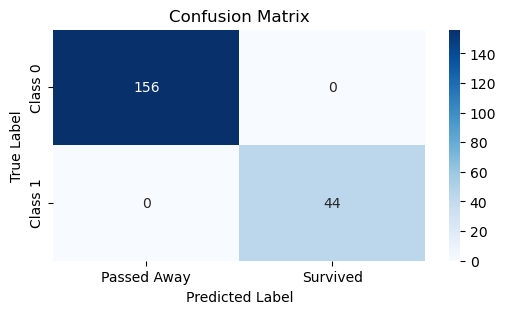


决策树结构:
├── 特征: Pclass
├── Pclass = 3
│   ├── 预测类别: 0
├── Pclass = 1
│   ├── 特征: Sex
│   ├── Sex = male
│   │   ├── 特征: Age_group
│   │   ├── Age_group = Child
│   │   │   ├── 特征: Fare_group
│   │   │   ├── Fare_group = Low
│   │   │   │   ├── 特征: Embarked
│   │   │   │   ├── Embarked = S
│   │   │   │   │   ├── 预测类别: 1
│   │   │   │   ├── Embarked = C
│   │   │   │       ├── 预测类别: 1
│   │   │   ├── Fare_group = High
│   │   │   │   ├── 预测类别: 1
│   │   │   ├── Fare_group = VeryHigh
│   │   │   │   ├── 预测类别: 1
│   │   │   ├── Fare_group = Medium
│   │   │       ├── 预测类别: 1
│   │   ├── Age_group = Adult
│   │   │   ├── 预测类别: 0
│   │   ├── Age_group = Young
│   │   │   ├── 预测类别: 0
│   │   ├── Age_group = Elder
│   │       ├── 预测类别: 0
│   ├── Sex = female
│       ├── 预测类别: 1
├── Pclass = 2
    ├── 特征: Age_group
    ├── Age_group = Child
    │   ├── 特征: Fare_group
    │   ├── Fare_group = Low
    │   │   ├── 预测类别: 1
    │   ├── Fare_group = High
    │   │   ├── 预测类别: 1
    │   ├── Fare_grou

In [4]:
import random
import pandas as pd
from sklearn import model_selection
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from matplotlib import pyplot as plt

def generate_titanic_data(n_samples=1000):
    data = []
    for _ in range(n_samples):
        sex = random.choice(['male', 'female'])
        pclass = random.choice(["1", "2", "3"])
        embarked = random.choice(['S', 'C', 'Q'])
        age = random.randint(1, 80)
        fare = random.uniform(0, 100)
        
        # 简单规则：女性和高舱位更易幸存
        if sex == 'female' and int(pclass) == 1:
            survived = 1
        elif age < 18 and int(pclass) <= 2:
            survived = 1
        else:
            survived = 0
        
        data.append([sex, pclass, embarked, age, fare, survived])
    
    df = pd.DataFrame(data, columns=['Sex', 'Pclass', 'Embarked', 'Age', 'Fare', 'Survived'])
    
    # 对连续特征进行离散化：这一步非常关键，因为ID3算法只能处理categorical variable
    # 年龄分组
    df['Age_group'] = pd.cut(df['Age'], bins=[0, 18, 35, 60, 100], labels=['Child', 'Young', 'Adult', 'Elder'])
    # 票价分组
    df['Fare_group'] = pd.cut(df['Fare'], bins=[0, 10, 30, 50, 100], labels=['Low', 'Medium', 'High', 'VeryHigh'])
    
    # 处理可能的NaN值
    df['Age_group'] = df['Age_group'].astype(str)
    df['Fare_group'] = df['Fare_group'].astype(str)
    
    # 删除原始的连续特征，只保留离散化后的特征
    df = df.drop(['Age', 'Fare'], axis=1)
    # debug发现survived不在最后一列，所以我们加上这一步，确保后续slice不会把其他列当成category了
    survived_col = df.pop('Survived')
    df['Survived'] = survived_col
    return df

# 生成数据并训练模型
titanic_simulated = generate_titanic_data()
print("数据集预览:")
print(titanic_simulated.head())

X = titanic_simulated.iloc[:, :-1]
y = titanic_simulated.iloc[:, -1]
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=200)
X_features = X.columns.tolist()

print("\n训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)
print("特征列表:", X_features)
print("\n训练集特征示例:")
print(X_train.head())
print("\n测试集特征示例:")
print(X_test.head())

# 训练决策树
dt_clf = DecisionTreeID3()
dt_clf.fit(X=X_train, y=y_train, features=X_features)

# 进行预测
predictions = dt_clf.predict(X_test, X_features)

print("\n预测结果（前10个）:", predictions[:10])
print("真实标签（前10个）:", y_test.tolist()[:10])

print("\nClassification Report:")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Passed Away', 'Survived'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 打印决策树结构（前几层）
print("\n决策树结构:")
dt_clf.print_tree()

### 5.2 决策树算法的改良（同Sklearn）

#### 5.2.1 CART算法与ID3算法的比较

Sklearn包中的决策树由CART (Classification and Regression Trees) 算法实现，于1984年提出，早于ID3的1986。CART算法分裂的准则是基尼不纯度，而不是信息增益。其优势在于支持分类和回归任务，也同时支持连续数据和类别数据，兼容度高于ID3。它会在连续数据中自动寻找分割点，是一种二叉树，不同于ID3的多叉树。它也可以自动处理缺失值，鲁棒性更强。

#### 5.2.2 CART算法简介

For a given dataset D, we denote the sub-dataset at some node t as $D_t$. For classes $C_1, ..., C_k$ at $D_t$, we denote the proportion of each class in the dataset as $ p_i = \frac{|C_i|}{|D|}$, for $i = 1, ..., k$, similar to the notations for ID3. We then difine the $ Gini \; impurity $ as:
$$
Gini(D_t) = \sum_{i=1}^{k}p_i(1-p_i) = 1 - \sum_{i = 1}^{k}p_i ^{2}
$$
Remark: Gini Impurity 测量在每个节点的样本纯度，换句话说，随机取样进行分类被分错的概率。其取值范围为[0, 1)。Gini越大说明classes越多，数据集越不纯。反之，Gini = 0 等价于$D_t$中的所有样本为同一类。

#### 算法步骤：
遍历所有特征 $A$ 和分割点 $s$（连续特征为threshold，对类别特征为类别子集），最小化分裂后的加权基尼不纯度。递归处理左右子节点，直到停止条件（如最大深度、最小样本数）。最小化基尼不纯度等价于最大化类别纯度。
$$
\mathop{\argmin}\limits_{A, s} \; Gini_{split}(A, s) = \frac{|D_{t+1}^{left}|}{|D_t|} Gini(D_{t+1}^{left}) + \frac{|D_{t+1}^{right}|}{|D_t|} Gini(D_{t+1}^{right})
$$
分裂示例：按$A$ = “年龄≤30”这个feature来分割：

左节点：3正例 + 1反例 → $Gini(D^{left})=0.375$ ; $\;\;$ 右节点：0正例 + 1反例 → $Gini(D^{right})=0$

加权基尼不纯度：$4/5 * 0.375 + 1/5 * 0  = 0.3$

#### 5.2.3 CART决策树的手动实现

代码框架由deepseek给出，关键部分（基尼不纯度计算、最佳分裂选择、递归建树）由我手写。

In [55]:
import numpy as np
from collections import Counter
from joblib import Parallel, delayed
import random


class Node():
    def __init__(self, n_samples=None):
        self.n_samples = n_samples  # 所有节点共享的属性，需要继承。虽然没什么用，但复习一下继承，并保证未来可扩展性。

class InternalNode(Node):
    """内部节点：存储分裂规则和子节点"""
    def __init__(self, feature, threshold, left, right, n_samples=None):
        super().__init__(n_samples)
        self.feature = feature      # 分裂特征索引,index!!
        self.threshold = threshold  # 分裂阈值
        self.left = left            # 左子树（<=阈值）
        self.right = right          # 右子树（>阈值）

class LeafNode(Node):
    """叶子节点：存储最终类别标签"""
    def __init__(self, label, n_samples=None):
        super().__init__(n_samples)
        self.label = label

class CARTClassifier():
    def __init__(self, max_depth=20, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features  # 用于随机森林的特征随机性，因此可选
        self.root = None
        self.feature_types = []  # 新增：记录每个特征的类型

    def fit(self, X, y):
        """训练入口"""
        if not isinstance(X, np.ndarray): # 确保他们是 NumPy 数组，不要python原生list或数据框
            X = np.array(X)
        if not isinstance(y, np.ndarray):
            y = np.array(y)
        self._detect_feature_types(X)
        self.root = self._build_tree(X, y, depth=0)

    def _detect_feature_types(self, X): 
        """改进版特征类型检测 - 修复混合数据问题""" 
        self.feature_types = [] 
        for i in range(X.shape[1]): 
            feature_column = X[:, i] 
            # 情况1：已经是数值类型(np.number)
            if np.issubdtype(type(feature_column[0]), float) or np.issubdtype(feature_column.dtype, np.number): 
                self.feature_types.append('numerical') 
                continue 
            # 情况2：检查是否包含字符串
            has_string = False 
            for val in feature_column: 
                if isinstance(val, str): 
                    has_string = True 
                    break 
            if has_string: 
                self.feature_types.append('categorical') 
                continue 
            # 情况3：尝试转换为数值 
            try: 
                unique_vals = np.unique(feature_column) 
                # 先检查是否都能转换为数值 
                converted = [] 
                for val in unique_vals: 
                    try: converted.append(float(val)) 
                    except (ValueError, TypeError): # 如果有任何值无法转换，直接判定为类别型 
                        self.feature_types.append('categorical') 
                        break 
                else: # 所有值都能转换为数值，进行进一步判断 
                    converted = np.array(converted) # 启发式规则：如果唯一值数量少且是整数，更可能是类别型 
                    if len(unique_vals) <= 10 and np.all(converted == converted.astype(int)): 
                        self.feature_types.append('categorical') 
                    else: self.feature_types.append('numerical') 
            except Exception: # 任何其他异常都判定为类别型 
                self.feature_types.append('categorical') 
        print("检测到的特征类型:", self.feature_types) # 调试输出

    def _build_tree(self, X, y, depth):
        """递归建树"""
        # print(f"当前深度: {depth}, 样本数: {len(y)}, 类别分布: {Counter(y)}")  # 调试
        # 终止条件1：所有样本属于同一类
        if len(set(y)) == 1:
            # print("所有样本同属一类")  # 调试
            return LeafNode(label=y[0])  # 返回最终标签叶子类

        # 终止条件2：达到最大深度或样本数不足,len(X)是n
        if depth >= self.max_depth or len(X) < self.min_samples_split:
            # print(f"终止条件触发，多数类: {Counter(y).most_common(1)}")  # 调试
            return LeafNode(label=self._majority_vote(y))  # 多数表决

        # 选择最佳分裂（需你实现_best_split）
        best_feature, best_threshold = self._best_split(X, y)
        if best_feature is None:  # 无法进一步分裂
            return LeafNode(label=self._majority_vote(y))

        # 递归构建左右子树
        if self.feature_types[best_feature] == 'numerical':
            left_idx = X[:, best_feature] <= best_threshold  # np.array，返回boolean list
        else:
            left_idx = np.isin(X[:, best_feature], best_threshold)  # 对类别型，best_threshold是类别集合
        right_idx = ~left_idx
        assert np.sum(left_idx) > 0 and np.sum(right_idx) > 0, "分裂导致空子集"
        left_subtree = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_subtree = self._build_tree(X[right_idx], y[right_idx], depth + 1)

        return InternalNode(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )

    def _gini(self, y):
        """计算基尼不纯度（需你实现）"""
        if len(y) == 0:
            return 0
        # 提示：使用公式 Gini = 1 - sum(p_i^2)
        
        # weight_list = []
        # for label in set(y):
        #     w_i = sum(1 for i in y if i == label) / len(y)
        #     weight_list.append(w_i)
        # Gini = 1
        # for w in weight_list:
        #     Gini -= w**2
        unique_labels, counts = np.unique(y, return_counts=True)  # 向量化
        probabilities = counts / len(y)
        Gini = 1 - np.sum(probabilities ** 2)
        return Gini

    def _best_split(self, X, y):
        """选择最优分裂特征和阈值（需你实现）"""
        best_gini = float('inf')
        best_feature, best_threshold = None, None

        # Random Features随机特征选择：这是Random Forest的核心之一
        n_features = X.shape[1]
        if self.max_features is not None:
            if self.max_features == 'sqrt':
                n_features_to_try = int(np.sqrt(n_features))
            elif self.max_features == 'log2':
                n_features_to_try = int(np.log2(n_features))
            elif isinstance(self.max_features, int):
                n_features_to_try = min(self.max_features, n_features)
            elif isinstance(self.max_features, float):
                n_features_to_try = int(self.max_features * n_features)
            else:
                n_features_to_try = n_features       # self.max_features = None的情况，也就是普通决策树
            
            # 随机选择特征子集
            feature_indices = np.random.choice(n_features, n_features_to_try, replace=False)
        else:
            feature_indices = range(n_features)

        for feature in feature_indices:
            if self.feature_types[feature] == 'numerical':
                try:
                    feature_values = X[:, feature].astype(float)
                    unique_val = np.unique(X[:, feature])
                except (ValueError, TypeError):
                    continue
                
                if len(unique_val) <= 1:   # 增强效率：unique_val = 1说明只有一类，无需分割
                    continue

                # 生成候选阈值：每两个unique相邻值的中点
                candidate_thresholds = []
                for i in range(len(unique_val) - 1):
                    threshold = (unique_val[i] + unique_val[i + 1]) / 2
                    candidate_thresholds.append(threshold)
                    
                for threshold in candidate_thresholds:
                    # 你的代码：计算分裂后的加权基尼不纯度
                    left_idx = X[:, feature] <= threshold  # 数值np.array的筛选，得到boolean的list
                    right_idx = ~left_idx
                    if np.sum(left_idx) == 0 or np.sum(left_idx) == len(y):  # 跳过无效分割
                        continue

                    n_left, n_right = np.sum(left_idx), np.sum(right_idx)   # True = 1, False = 0
                    gini_left = self._gini(y[left_idx])
                    gini_right = self._gini(y[right_idx])  # not left
                    weighted_gini = (n_left / len(y)) * gini_left + (n_right / len(y)) * gini_right

                    if weighted_gini < best_gini:
                        best_gini = weighted_gini
                        best_feature = feature
                        best_threshold = threshold

            else:
                # 类别型特征处理
                categories = np.unique(X[:, feature])
                # 尝试所有可能的类别子集划分
                # weighted_gini = None
                for category_set in self._get_category_splits(categories):
                    left_idx = np.isin(X[:, feature], category_set)  # 类别np.array的筛选，得到boolean的list
                    right_idx = ~left_idx
                    if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:  # 跳过无效分割，正常情况下occurs when category set是全集
                        print("无效分割", category_set)
                        continue
                    
                    n_left, n_right = np.sum(left_idx), np.sum(right_idx)   # True = 1, False = 0
                    gini_left = self._gini(y[left_idx])    # 以下计算逻辑相同 
                    gini_right = self._gini(y[right_idx])  # not left
                    weighted_gini = (n_left / len(y)) * gini_left + (n_right / len(y)) * gini_right
                # if weighted_gini is None:
                #     continue
                    if weighted_gini < best_gini:
                        best_gini = weighted_gini
                        best_feature = feature  # this is an index!
                        best_threshold = category_set

        return best_feature, best_threshold
    
    def _get_category_splits(self, categories):
        """生成唯一的非空真子集划分 若有全集，则必报错"""
        n = len(categories)
        # 只需遍历前一半的组合（避免A/B和B/A的镜像重复）
        for i in range(1, 2**(n-1)):  
            mask = list(map(int, bin(i)[2:].zfill(n)))
            subset = [cat for cat, m in zip(categories, mask) if m]
            yield subset

    def _majority_vote(self, y):
        """返回多数类别（已实现）"""
        if len(y) == 0:
            raise RuntimeError("空标签列表，请检查分裂逻辑")  # 改为抛出异常而非返回None
        return Counter(y).most_common(1)[0][0]   # Counter(y)返回字典相当于GROUP BY element COUNT(*)，counter.most_common(1) → [('apple', 20)]

    def predict(self, X):
        """预测入口"""
        if not isinstance(X, np.ndarray): # 确保他们是 NumPy 数组，不要python原生list或数据框
            X = np.array(X)
        return np.array([self._predict_one(x, self.root) for x in X])

    def _predict_one(self, x, node):
        """单样本预测"""
        # print(f"this is the prediction for datapoint x: {x}")  # 测试用
        if isinstance(node, LeafNode):
            return node.label

        if self.feature_types[node.feature] == 'numerical':
            if x[node.feature] <= node.threshold:  # x[node.feature] 是一个标量，因为x只是一个row
                return self._predict_one(x, node.left)  # 也通过递归实现预测，直到到达leaf
            else:
                return self._predict_one(x, node.right)
        else:
        # 类别型特征：检查是否属于阈值集合
        # 注意：对类别型特征，node.threshold存储的是类别子集（如 {'red', 'blue'}）
            feature_value = x[node.feature]
            if feature_value in node.threshold:
                return self._predict_one(x, node.left)
            else:
                return self._predict_one(x, node.right)

#### 5.2.4 测试
接下来我们用与5.1.4相同生成的泰坦尼克号幸存者数据集来测试我们的模型。为保证随机性，我们不在生成时设定seed，但为了reproducibility，我们在这一步不再重复生成数据集，因此请先运行5.1.4


训练集形状: (800, 5)
测试集形状: (200, 5)
检测到的特征类型: ['categorical', 'categorical', 'categorical', 'categorical', 'categorical']

预测结果（前10个）: [0 1 0 1 0 0 0 0 0 0]
真实标签（前10个）: [0 1 0 1 0 0 0 0 0 0]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       156
           1       1.00      1.00      1.00        44

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



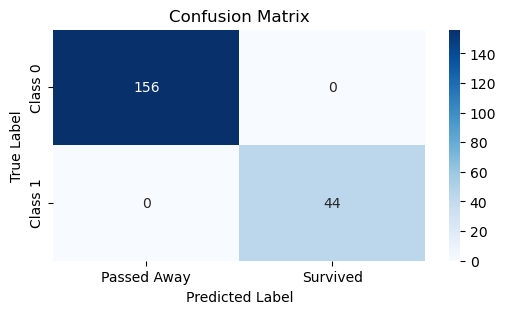


决策树结构:
├── 特征: Pclass
├── Pclass = 3
│   ├── 预测类别: 0
├── Pclass = 1
│   ├── 特征: Sex
│   ├── Sex = male
│   │   ├── 特征: Age_group
│   │   ├── Age_group = Child
│   │   │   ├── 特征: Fare_group
│   │   │   ├── Fare_group = Low
│   │   │   │   ├── 特征: Embarked
│   │   │   │   ├── Embarked = S
│   │   │   │   │   ├── 预测类别: 1
│   │   │   │   ├── Embarked = C
│   │   │   │       ├── 预测类别: 1
│   │   │   ├── Fare_group = High
│   │   │   │   ├── 预测类别: 1
│   │   │   ├── Fare_group = VeryHigh
│   │   │   │   ├── 预测类别: 1
│   │   │   ├── Fare_group = Medium
│   │   │       ├── 预测类别: 1
│   │   ├── Age_group = Adult
│   │   │   ├── 预测类别: 0
│   │   ├── Age_group = Young
│   │   │   ├── 预测类别: 0
│   │   ├── Age_group = Elder
│   │       ├── 预测类别: 0
│   ├── Sex = female
│       ├── 预测类别: 1
├── Pclass = 2
    ├── 特征: Age_group
    ├── Age_group = Child
    │   ├── 特征: Fare_group
    │   ├── Fare_group = Low
    │   │   ├── 预测类别: 1
    │   ├── Fare_group = High
    │   │   ├── 预测类别: 1
    │   ├── Fare_grou

In [56]:
X = titanic_simulated.iloc[:, :-1]
y = titanic_simulated.iloc[:, -1]
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=200)
X_features = X.columns.tolist()

print("\n训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)

# 训练决策树
dt_cart = CARTClassifier()
dt_cart.fit(X=X_train, y=y_train)

# 进行预测
predictions = dt_cart.predict(X_test)

print("\n预测结果（前10个）:", predictions[:10])
print("真实标签（前10个）:", np.array(y_test)[:10])

print("\nClassification Report:")
print(classification_report(y_test, predictions))


cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Passed Away', 'Survived'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 打印决策树结构（前几层）
print("\n决策树结构:")
dt_clf.print_tree()

接下来测试模型对于经典数据集的分类，包括二维平面的球形，同心圆和月亮，也包括混合类别的数据。

In [57]:
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn import model_selection
import pandas as pd

# 测试1：blob数据 
print("测试1: Blob数据") 
X_blob, y_blob = make_blobs(n_samples=200, centers=3, random_state=42)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_blob, y_blob, test_size=0.2, random_state=42) 
clf = CARTClassifier(max_depth=10, min_samples_split=5) 
clf.fit(X_train, y_train) 
predictions = clf.predict(X_test) 
accuracy = np.mean(predictions == y_test) 
print(f"Blob数据准确率: {accuracy:.3f}") 
print(classification_report(y_test, predictions))

# 测试2：moons数据,也可以改成circle
print("\n测试2: Moons数据") 
X_circle, y_circle = make_moons(n_samples=200, noise=0.1, random_state=42) 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_circle, y_circle, test_size=0.2, random_state=42) 
clf2 = CARTClassifier(max_depth=15, min_samples_split=3) 
clf2.fit(X_train, y_train) 
predictions = clf2.predict(X_test) 
accuracy = np.mean(predictions == y_test) 
print(f"Circles数据准确率: {accuracy:.3f}") 
print(classification_report(y_test, predictions))

# 测试3：混合数据（数值+类别） 
print("\n测试3: 混合数据") 
np.random.seed(42) 
# 生成数值特征，并根据类别添加偏移量
n_samples = 100
data = {
    'num1': np.concatenate([
        np.random.randn(n_samples // 3) - 10,  # 类别A的num1均值=-10
        np.random.randn(n_samples // 3),       # 类别B的num1均值=0
        np.random.randn(n_samples // 3 + 1) + 10  # 类别C的num1均值=+10
    ]),
    'num2': np.concatenate([
        np.random.randn(n_samples // 3) * 0.5,  # 类别A的num2方差较小
        np.random.randn(n_samples // 3) * 1.6,  # 类别B的num2方差中等
        np.random.randn(n_samples // 3 + 1) * 4  # 类别C的num2方差较大
    ]),
    'class': ['A'] * (n_samples // 3) + ['B'] * (n_samples // 3) + ['C'] * (n_samples // 3 + 1)
}
X_mixed = pd.DataFrame(data)
y_mixed = (X_mixed.iloc[:, 0].astype(float) + X_mixed.iloc[:, 1].astype(float) > 0).astype(int) 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_mixed, y_mixed, test_size=0.2, random_state=42) 
clf3 = CARTClassifier(max_depth=10, min_samples_split=5) 
clf3.fit(X_train, y_train) 
predictions = clf3.predict(X_test) 
accuracy = np.mean(predictions == y_test) 
print(f"混合数据准确率: {accuracy:.3f}")
print(classification_report(y_test, predictions))


测试1: Blob数据
检测到的特征类型: ['numerical', 'numerical']
Blob数据准确率: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        13

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


测试2: Moons数据
检测到的特征类型: ['numerical', 'numerical']
Circles数据准确率: 0.975
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        22
           1       1.00      0.94      0.97        18

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40


测试3: 混合数据
检测到的特征类型: ['numerical', 'numerical', 'categorical']
混合数据准确率: 0.950
              precision    recall  f1-score   support

           0       0.9

### 5.3 随机森林
#### 5.3.1 随机森林的原理及与决策树的比较
随机森林（Random Forest）是基于 CART决策树算法的改良，而非 ID3 或 C4.5。它的核心改进是通过 集成学习（Ensemble Learning） 和 随机性注入 来提升模型的泛化能力和鲁棒性。它的改进点主要有：
1. 自助采样（Bagging, for Bootstrap Aggregating）： 每棵树的训练数据通过 有放回随机采样（Bootstrap） 从原始数据集中抽取，Bagging 主要减少方差项。
2. 特征随机性（Random Feature Subspace）： 每棵树在分裂时，仅从全部特征的随机子集（通常大小为 $ \sqrt p $ 或 $\log_2(p)$， 其中p是总特征数）中选择最优分裂特征。这样做可以打破特征间的强相关性，避免所有树同质化（否则森林会退化为单棵树的重复）并进一步降低方差，提升对噪声和异常值的鲁棒性。
3. OOB验证 (Out of Bag)：OOB 样本是天然未参与该树训练的验证集。其作用有：无需额$D_{test}$，直接利用 OOB 样本计算模型的泛化误差，省去显式划分验证集的开销；无偏估计：所有树的 OOB 预测组合相当于交叉验证。

注意，随机森林类完全基于我们上面写好的CARTClassifier。

#### 5.3.2 随机森林的手动代码实现

In [58]:
class RandomForestClassifier:
    def __init__(self, n_estimators=100, max_depth=20, min_samples_split=2, 
                 max_features='sqrt', n_jobs=None, random_state=None):
        """
        随机森林分类器
        
        参数解释：
        - n_estimators: 树的数量（集成学习的"投票者"数量）
        - max_depth: 单棵树的最大深度
        - min_samples_split: 分裂所需最小样本数
        - max_features: 每棵树考虑的最大特征数（随机特征选择）
        - n_jobs: 并行作业数（建议使用-1，也就是全部CPU核心，但要小心资源占用）
        - random_state: 随机种子，确保结果可复现
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.trees = []
        self.oob_score_ = 0.0

    def fit(self, X, y):
        if not isinstance(X, np.ndarray):  # 老规矩，我们需要np数组而不是dataframe
            X = np.array(X)
        if not isinstance(y, np.ndarray):
            y = np.array(y)
            
        self.trees = []
        self.classes_ = np.unique(y)
        n_samples = X.shape[0]
        
        # 设置随机种子，也可以手动写死
        if self.random_state is not None:
            np.random.seed(self.random_state)
            random.seed(self.random_state)
        
        # 初始化OOB预测存储
        oob_predictions = [[] for _ in range(n_samples)]
        
        # 并行训练决策树
        if self.n_jobs is not None and self.n_jobs != 1:
            # 为每棵树生成不同的随机种子
            seeds = [int(s) for s in np.random.randint(0, 10000, self.n_estimators)]
            
            # 并行训练
            results = Parallel(n_jobs=self.n_jobs)(
                delayed(self._grow_tree)(X, y, seed) 
                for seed in seeds
            )
            
            # 分离树和OOB预测
            for tree, oob_indices, oob_preds in results:
                self.trees.append(tree)
                for idx, pred in zip(oob_indices, oob_preds):
                    oob_predictions[idx].append(pred)
        else:
            # 串行训练
            for i in range(self.n_estimators):
                seed = int(np.random.randint(0, 10000)) if self.random_state is None else self.random_state + i
                tree, oob_indices, oob_preds = self._grow_tree(X, y, seed)
                self.trees.append(tree)
                for idx, pred in zip(oob_indices, oob_preds):
                    oob_predictions[idx].append(pred)
        
        # 计算OOB准确率
        self.oob_score_ = self._compute_oob_accuracy(y, oob_predictions)
        print(f"OOB准确率: {self.oob_score_:.4f}")
        
        return self

    def _grow_tree(self, X, y, seed):
        """
        生长单棵树
        
        这里实现了Random Forest的两个核心随机性：
        1. Bagging（Bootstrap Aggregating）：有放回抽样
        2. Random Feature Selection：在每个节点随机选择特征子集
        """
        # 设置当前树的随机种子
        seed = int(seed) # 注意numpy.int64和int的区别，会造成TypeError
        np.random.seed(seed)
        random.seed(seed)
        
        n_samples = X.shape[0]
        
        # === BAGGING部分 ===
        # 有放回的Bootstrap抽样，生成训练集
        bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)
        
        # 计算袋外样本（Out-of-Bag, OOB）
        # OOB样本是那些在bootstrap抽样中没有被选中的样本
        oob_indices = np.setdiff1d(np.arange(n_samples), np.unique(bootstrap_indices))
        
        # 创建决策树
        tree = CARTClassifier(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            max_features=self.max_features  # 这个参数会在_best_split中实现随机特征选择
        )
        
        # 用Bootstrap样本训练树
        tree.fit(X[bootstrap_indices], y[bootstrap_indices])
        
        # 用OOB样本进行预测（用于计算OOB准确率）
        oob_predictions = []
        if len(oob_indices) > 0:
            oob_predictions = tree.predict(X[oob_indices])
        
        return tree, oob_indices, oob_predictions

    def _compute_oob_accuracy(self, y, oob_predictions):
        """
        计算袋外准确率
        
        OOB准确率是Random Forest的一个重要特性：
        - 每个样本都会成为某些树的OOB样本
        - 用这些树对该样本进行预测并投票
        - 无需额外的验证集就能估计模型性能
        """
        correct = 0
        total = 0
        
        for i, preds in enumerate(oob_predictions):
            if len(preds) > 0:  # 只考虑有OOB预测的样本
                total += 1
                # 多数投票选出最终预测
                final_pred = Counter(preds).most_common(1)[0][0]
                if final_pred == y[i]:
                    correct += 1
        
        return correct / total if total > 0 else 0.0

    def predict(self, X):
        """预测类别"""
        if not isinstance(X, np.ndarray):
            X = np.array(X)
            
        # 收集所有树的预测
        all_predictions = []
        for tree in self.trees:
            preds = tree.predict(X)
            all_predictions.append(preds)
        
        # 转换为numpy数组方便处理
        all_predictions = np.array(all_predictions)  # shape: (n_trees, n_samples)
        
        # 对每个样本进行多数投票
        final_predictions = []
        for i in range(X.shape[0]):
            sample_predictions = all_predictions[:, i]
            # 投票选出最终预测
            final_pred = Counter(sample_predictions).most_common(1)[0][0]
            final_predictions.append(final_pred)
        
        return np.array(final_predictions)

    def predict_proba(self, X):
        """预测类别概率"""
        if not isinstance(X, np.ndarray):
            X = np.array(X)
            
        # 收集所有树的预测
        all_predictions = []
        for tree in self.trees:
            preds = tree.predict(X)
            all_predictions.append(preds)
        
        all_predictions = np.array(all_predictions)  # shape: (n_trees, n_samples)
        
        # 计算每个类别的概率
        n_classes = len(self.classes_)
        probabilities = np.zeros((X.shape[0], n_classes))
        
        for i in range(X.shape[0]):
            sample_predictions = all_predictions[:, i]
            # 计算每个类别的投票比例
            for j, class_label in enumerate(self.classes_):
                count = np.sum(sample_predictions == class_label)
                probabilities[i, j] = count / len(sample_predictions)
        
        return probabilities


# 关于并行处理的建议
def get_optimal_n_jobs():
    """
    获取建议的并行作业数
    
    关于n_jobs的选择：
    - n_jobs=1: 串行处理，最安全但最慢
    - n_jobs=-1: 使用所有CPU核心，最快但可能占用过多资源
    - n_jobs=None: 串行处理（默认）
    - n_jobs=2,3,4...: 使用指定数量的核心
    
    建议策略：
    - 小数据集(<10000样本): 使用串行处理或少量核心
    - 大数据集(>10000样本): 可以使用更多核心
    - 生产环境: 建议不要使用-1，而是具体指定核心数
    """
    import multiprocessing
    n_cores = multiprocessing.cpu_count()
    
    # 保留1-2个核心给系统使用
    recommended = max(1, n_cores - 2)
    
    print(f"系统CPU核心数: {n_cores}")
    print(f"建议使用核心数: {recommended}")
    print(f"使用方法: RandomForestClassifier(n_jobs={recommended})")
    
    return recommended

#### 5.3.3 简单的二分数据测试

In [59]:
np.random.seed(42)
X = np.random.randn(1000, 10)   # 10-dim
print(X[:3, :])
y = np.where(X[:, 0] + X[:, 1] > 0, 1, 0)

# 获取建议的并行核心数
recommended_jobs = get_optimal_n_jobs()

# 训练随机森林
rf = RandomForestClassifier(
    n_estimators=100,  # 减少树的数量用于快速测试
    max_depth=15,
    max_features='sqrt',
    n_jobs=recommended_jobs,    # 使用建议的核心数
    random_state=200            # 确保结果可复现
)

print("\n开始训练随机森林...")
rf.fit(X, y)

# 测试预测
sample = np.random.randn(5, 10)
predictions = rf.predict(sample)
probabilities = rf.predict_proba(sample)

print(f"\n预测结果:")
print(f"预测类别: {predictions}")
print(f"类别概率: {probabilities}")
print(f"OOB准确率: {rf.oob_score_:.4f}")

[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
   1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783 -0.56228753
  -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819 -0.54438272  0.11092259
  -1.15099358  0.37569802 -0.60063869 -0.29169375]]
系统CPU核心数: 28
建议使用核心数: 26
使用方法: RandomForestClassifier(n_jobs=26)

开始训练随机森林...
OOB准确率: 0.9650

预测结果:
预测类别: [0 0 1 1 1]
类别概率: [[0.79 0.21]
 [0.52 0.48]
 [0.08 0.92]
 [0.07 0.93]
 [0.02 0.98]]
OOB准确率: 0.9650


### 5.4 总结
#### 5.4.1 RF与SVM的对比

| **特性**            | **随机森林**                      | **SVM**                          |
|---------------------|-----------------------------------|----------------------------------|
| **数据缩放**        | 不需要                            | 必须（对距离敏感）               |
| **特征重要性**      | 直接提供                          | 无（需借助permutation importance）|
| **计算效率**        | 适合大样本（可并行）              | 适合小样本（O(n²~n³)）           |
| **高维适应**        | 优秀（自动特征选择，可处理基因表达数据、文本特征等高维数据）|     1000-dim以下，配合kernel可以更高，但计算效率与精确度通常不如RF             
| **解释性**          | 中等（可通过特征重要性解释）      | 低（尤其非线性核）               |
| **默认表现**        | 通常较好（无需调参）              | 依赖hyper-parameter的调参（核函数/C/gamma）       |
| **缺失值处理**      | 支持                              | 不支持                           |

选择随机森林当：

1. 数据包含混合类型特征（数值+类别）。
2. 需要快速基线模型（默认参数表现良好）。
3. 特征重要性分析是关键需求(对解释性要求高)
4. 数据有缺失或噪声较多。

选择SVM当：

1. 数据维度适中（如 < 1000 特征）。
2. 类别间存在明显几何间隔（如图像分类）。
3. 样本量较小（如 < 10,000 样本）。
4. 明确需要最大化分类间隔的场景。

#### 5.4.2 RF的General Test

In [60]:
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import classification_report
from sklearn import model_selection
import pandas as pd

# 测试1：blob数据 
print("测试1: Blob数据") 
X_blob, y_blob = make_blobs(n_samples=200, centers=3, random_state=42)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_blob, y_blob, test_size=0.2, random_state=42) 
clf = RandomForestClassifier(n_estimators=50,
    max_depth=15,
    max_features='sqrt',
    n_jobs=recommended_jobs,
    random_state=200) 
clf.fit(X_train, y_train) 
predictions = clf.predict(X_test) 
accuracy = np.mean(predictions == y_test) 
print(f"Blob数据准确率: {accuracy:.3f}") 
print(classification_report(y_test, predictions))

# 测试2：moons数据,也可以改成circle
print("\n测试2: Moons数据") 
X_circle, y_circle = make_moons(n_samples=200, noise=0.15, random_state=42)  # noise我搞大了点
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_circle, y_circle, test_size=0.2, random_state=42) 
clf2 = RandomForestClassifier(n_estimators=200,
    max_depth=15,
    max_features='sqrt',
    n_jobs=recommended_jobs,
    random_state=200) 
clf2.fit(X_train, y_train) 
predictions = clf2.predict(X_test) 
accuracy = np.mean(predictions == y_test) 
print(f"Moons数据准确率: {accuracy:.3f}") 
print(classification_report(y_test, predictions))

# 测试3：混合数据（数值+类别） 
print("\n测试3: 混合数据") 
np.random.seed(42) 
# 生成数值特征，并根据类别添加偏移量
n_samples = 100
data = {
    'num1': np.concatenate([
        np.random.randn(n_samples // 3) - 10,  # 类别A的num1均值=-10
        np.random.randn(n_samples // 3),       # 类别B的num1均值=0
        np.random.randn(n_samples // 3 + 1) + 10  # 类别C的num1均值=+10
    ]),
    'num2': np.concatenate([
        np.random.randn(n_samples // 3) * 0.5,  # 类别A的num2方差较小
        np.random.randn(n_samples // 3) * 1.6,  # 类别B的num2方差中等
        np.random.randn(n_samples // 3 + 1) * 4  # 类别C的num2方差较大
    ]),
    'class': ['A'] * (n_samples // 3) + ['B'] * (n_samples // 3) + ['C'] * (n_samples // 3 + 1)
}
X_mixed = pd.DataFrame(data)
y_mixed = (X_mixed.iloc[:, 0].astype(float) + X_mixed.iloc[:, 1].astype(float) > 0).astype(int) 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_mixed, y_mixed, test_size=0.2, random_state=42) 
clf3 = RandomForestClassifier(n_estimators=50,
    max_depth=15,
    max_features='sqrt',
    n_jobs=recommended_jobs,
    random_state=200) 
clf3.fit(X_train, y_train) 
predictions = clf3.predict(X_test) 
accuracy = np.mean(predictions == y_test) 
print(f"混合数据准确率: {accuracy:.3f}")
print(classification_report(y_test, predictions))


测试1: Blob数据
OOB准确率: 1.0000
Blob数据准确率: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        13

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


测试2: Moons数据
OOB准确率: 0.9750
Moons数据准确率: 0.925
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        22
           1       1.00      0.83      0.91        18

    accuracy                           0.93        40
   macro avg       0.94      0.92      0.92        40
weighted avg       0.93      0.93      0.92        40


测试3: 混合数据
OOB准确率: 0.9375
混合数据准确率: 0.950
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.90      1.00      0.95        

对比一下调包

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# 月亮数据对比，看看和我自己写的有多大区别
X_circle, y_circle = make_moons(n_samples=200, noise=0.15, random_state=42) 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_circle, y_circle, test_size=0.2, random_state=42) 
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train) 
predictions = rf.predict(X_test) 
accuracy = np.mean(predictions == y_test) 
print(f"Monns数据准确率: {accuracy:.3f}") 
print(classification_report(y_test, predictions))

# （有概率）还是比我自己写的强一点

Monns数据准确率: 0.950
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.89      0.94        18

    accuracy                           0.95        40
   macro avg       0.96      0.94      0.95        40
weighted avg       0.95      0.95      0.95        40

